In [1]:

path = '/home/apollo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [3]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
# import dabest

from statsmodels.stats.proportion import proportions_chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib widget

import helper_functions as hf


In [4]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [5]:

os.chdir(tables_path + '/figure_6/')

filename = 'Figure_Ripple_Coincidence.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]
shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,side,shank_1,shank_2,shanks_distance,ripple_coincidence_100,ripple_coincidence_50,ripple_coincidence_5,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.910631,0.889816,0.685540,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.879714,0.850547,0.593016,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.848699,0.810002,0.486759,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.828032,0.784195,0.409497,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.803889,0.760559,0.362618,5.0
...,...,...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,0.829047,0.786305,0.501553,2.0
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.731796,0.670777,0.298289,3.0
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,0.848980,0.811712,0.555995,1.0
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.740830,0.681834,0.307653,2.0


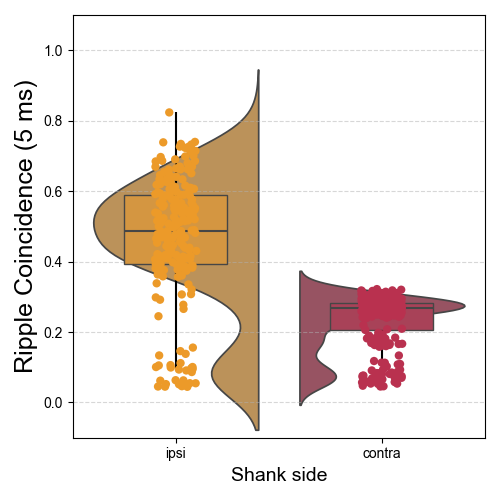

In [6]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence_5", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)

box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence_5',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence_5',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim([-0.1,1.1])
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_Ripple_Coincidence_5ms.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



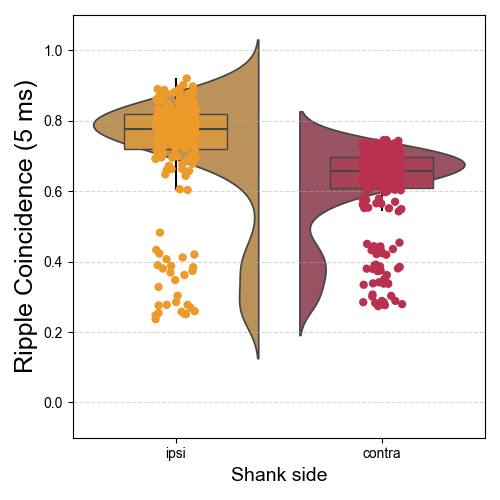

In [7]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence_50", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)

box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence_50',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence_50',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim([-0.1,1.1])
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_Ripple_Coincidence_50ms.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



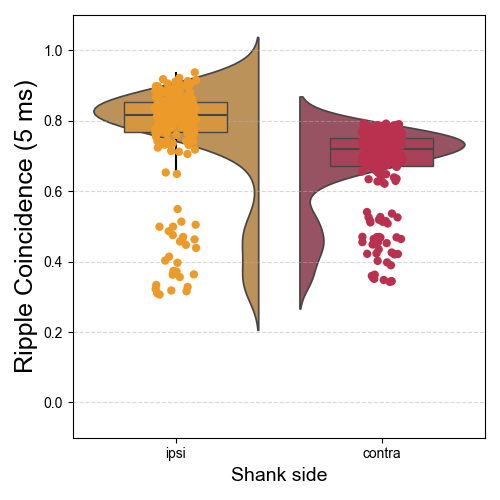

In [8]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence_100", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)

box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence_100',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence_100',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim([-0.1,1.1])
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_Ripple_Coincidence_100ms.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [6]:
rat = np.tile(df['rat'],3)
session = np.tile(df['session'],3)
side = np.tile(df['side'],3)
analysis_values = np.concatenate([df['ripple_coincidence_5'],df['ripple_coincidence_50'],df['ripple_coincidence_100']])
analysis_type = np.repeat(['coinc_5','coinc_50','coinc_100'],[len(df['ripple_coincidence_5']),len(df['ripple_coincidence_50']),len(df['ripple_coincidence_100'])])

data_dict = {'rat':rat,
            'session':session,
            'side':side,
            'analysis_type':analysis_type,
            'analysis_values':analysis_values
            }
df_dabest = pd.DataFrame(data_dict)
df_dabest['side_analysis'] = df_dabest['side'] + '_' + df_dabest['analysis_type']
df_dabest['coinc_value'] = df_dabest['analysis_type'].replace({'coinc_5': 5, 'coinc_50': 50, 'coinc_100': 100})
df_dabest

# coinc_value is continuous, analysis_type is categorical

,rat,session,side,analysis_type,analysis_values,side_analysis,coinc_value
0,Ach,Achilles_10252013,ipsi,coinc_5,0.685540,ipsi_coinc_5,5
1,Ach,Achilles_10252013,ipsi,coinc_5,0.593016,ipsi_coinc_5,5
2,Ach,Achilles_10252013,ipsi,coinc_5,0.486759,ipsi_coinc_5,5
3,Ach,Achilles_10252013,ipsi,coinc_5,0.409497,ipsi_coinc_5,5
4,Ach,Achilles_10252013,ipsi,coinc_5,0.362618,ipsi_coinc_5,5
...,...,...,...,...,...,...,...
1390,Gat,Gatsby_08282013,ipsi,coinc_100,0.829047,ipsi_coinc_100,100
1391,Gat,Gatsby_08282013,ipsi,coinc_100,0.731796,ipsi_coinc_100,100
1392,Gat,Gatsby_08282013,ipsi,coinc_100,0.848980,ipsi_coinc_100,100
1393,Gat,Gatsby_08282013,ipsi,coinc_100,0.740830,ipsi_coinc_100,100


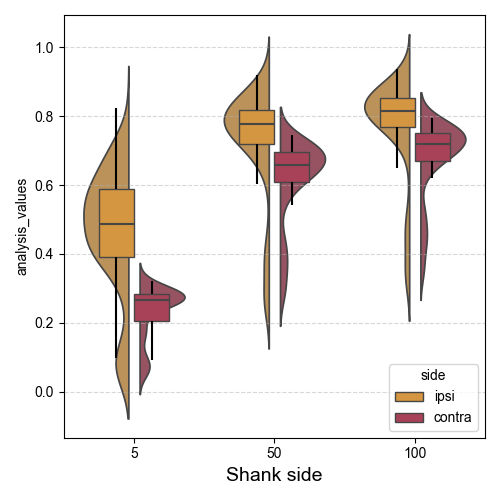

In [7]:

plt.figure(figsize=(5,5))
box = sns.boxplot(data=df_dabest, x='coinc_value', hue="side", y='analysis_values',
            order=[5,50,100], hue_order=["ipsi", "contra"], 
            showfliers=False, showcaps=False, whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),palette=my_pal,
            width=0.5)  # Using the custom color palette
box = sns.violinplot(data=df_dabest, x='coinc_value', hue="side", y='analysis_values',
            order=[5,50,100], hue_order=["ipsi", "contra"],
            palette=my_pal,fill=True,inner = None,split=True,gap = 0.2,
            legend=False,density_norm='width',saturation=0.5,bw_adjust=1)  # Using the custom color palette


plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.ylim([0,1])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_ripple_coincidence.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)



In [8]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model without interaction
formula = "analysis_values ~ C(side, Treatment(reference='ipsi')) + C(analysis_type, Treatment(reference='coinc_5'))"

re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_dabest, groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                  Mixed Linear Model Regression Results
Model:                            MixedLM               Dependent Variable:               analysis_values
No. Observations:                 1395                  Method:                           REML           
No. Groups:                       4                     Scale:                            0.0101         
Min. group size:                  108                   Log-Likelihood:                   1197.9378      
Max. group size:                  594                   Converged:                        Yes            
Mean group size:                  348.8                                                                  
---------------------------------------------------------------------------------------------------------
                                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [9]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "analysis_values ~ C(side, Treatment(reference='ipsi')) * coinc_value"

re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_dabest,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())




                                Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              analysis_values
No. Observations:                1395                 Method:                          REML           
No. Groups:                      4                    Scale:                           0.0140         
Min. group size:                 108                  Log-Likelihood:                  961.5439       
Max. group size:                 594                  Converged:                       Yes            
Mean group size:                 348.8                                                                
------------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [10]:
result.fe_params

Intercept                                                     0.462241
C(side, Treatment(reference='ipsi'))[T.contra]               -0.227717
coinc_value                                                   0.003170
C(side, Treatment(reference='ipsi'))[T.contra]:coinc_value    0.001443
dtype: float64

In [12]:
0.462241 + 0.003170*100

0.7792410000000001

In [99]:
# Get the confidence intervals of the model coefficients
conf_intervals = result.conf_int()

# Print confidence intervals
print(conf_intervals)

                                                           0         1
Intercept                                           0.347168  0.577315
C(side, Treatment(reference='ipsi'))[T.contra]     -0.248480 -0.206953
coinc_value                                         0.002937  0.003403
C(side, Treatment(reference='ipsi'))[T.contra]:...  0.001122  0.001764
rat Var                                            -0.595946  2.503773
session Var                                        -0.015742  0.051838


In [100]:
result.pvalues

Intercept                                                      3.461769e-15
C(side, Treatment(reference='ipsi'))[T.contra]                1.720397e-102
coinc_value                                                   9.428407e-157
C(side, Treatment(reference='ipsi'))[T.contra]:coinc_value     1.197075e-18
rat Var                                                        2.276919e-01
session Var                                                    2.951593e-01
dtype: float64

In [101]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's posthoc test
posthoc = pairwise_tukeyhsd(df_dabest['analysis_values'], df_dabest['side_analysis'])
# Print the results
print(posthoc)


          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2     meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------
contra_coinc_100  contra_coinc_5  -0.4443    0.0 -0.4795 -0.4091   True
contra_coinc_100 contra_coinc_50  -0.0622    0.0 -0.0975  -0.027   True
contra_coinc_100  ipsi_coinc_100   0.0925    0.0  0.0563  0.1287   True
contra_coinc_100    ipsi_coinc_5  -0.2128    0.0  -0.249 -0.1766   True
contra_coinc_100   ipsi_coinc_50    0.048 0.0022  0.0118  0.0842   True
  contra_coinc_5 contra_coinc_50   0.3821    0.0  0.3469  0.4173   True
  contra_coinc_5  ipsi_coinc_100   0.5368    0.0  0.5006   0.573   True
  contra_coinc_5    ipsi_coinc_5   0.2315    0.0  0.1953  0.2678   True
  contra_coinc_5   ipsi_coinc_50   0.4923    0.0  0.4561  0.5285   True
 contra_coinc_50  ipsi_coinc_100   0.1547    0.0  0.1185  0.1909   True
 contra_coinc_50    ipsi_coinc_5  -0.1505    0.0 -0.1867 -0.1143

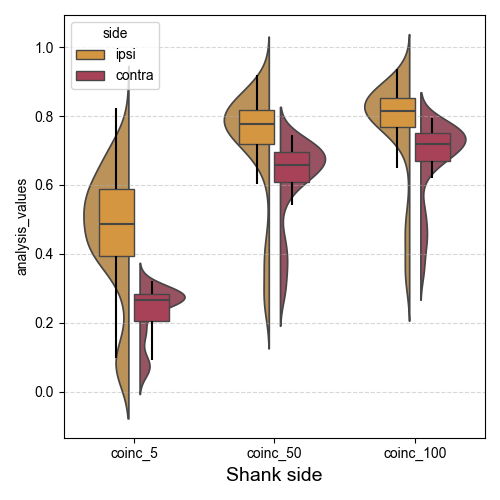

In [102]:

plt.figure(figsize=(5,5))
box = sns.boxplot(data=df_dabest, x='analysis_type', hue="side", y='analysis_values',
            order=['coinc_5','coinc_50','coinc_100'], hue_order=["ipsi", "contra"], 
            showfliers=False, showcaps=False, whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),palette=my_pal,
            width=0.5)  # Using the custom color palette
box = sns.violinplot(data=df_dabest, x='analysis_type', hue="side", y='analysis_values',
            order=['coinc_5','coinc_50','coinc_100'], hue_order=["ipsi", "contra"],
            palette=my_pal,fill=True,inner = None,split=True,gap = 0.2,
            legend=False,density_norm='width',saturation=0.5,bw_adjust=1)  # Using the custom color palette


plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.ylim([0,1])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_ripple_coincidence.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)



In [64]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "analysis_values ~ C(side, Treatment(reference='ipsi')) * C(analysis_type,Treatment(reference='coinc_5'))"

re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_dabest,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())




                                                         Mixed Linear Model Regression Results
Model:                                           MixedLM                               Dependent Variable:                               analysis_values
No. Observations:                                1395                                  Method:                                           REML           
No. Groups:                                      4                                     Scale:                                            0.0091         
Min. group size:                                 108                                   Log-Likelihood:                                   1259.9989      
Max. group size:                                 594                                   Converged:                                        Yes            
Mean group size:                                 348.8                                                                                      

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [65]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's posthoc test
posthoc = pairwise_tukeyhsd(df_dabest['analysis_values'], df_dabest['side_analysis'])
# Print the results
print(posthoc)


          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2     meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------
contra_coinc_100  contra_coinc_5  -0.4443    0.0 -0.4795 -0.4091   True
contra_coinc_100 contra_coinc_50  -0.0622    0.0 -0.0975  -0.027   True
contra_coinc_100  ipsi_coinc_100   0.0925    0.0  0.0563  0.1287   True
contra_coinc_100    ipsi_coinc_5  -0.2128    0.0  -0.249 -0.1766   True
contra_coinc_100   ipsi_coinc_50    0.048 0.0022  0.0118  0.0842   True
  contra_coinc_5 contra_coinc_50   0.3821    0.0  0.3469  0.4173   True
  contra_coinc_5  ipsi_coinc_100   0.5368    0.0  0.5006   0.573   True
  contra_coinc_5    ipsi_coinc_5   0.2315    0.0  0.1953  0.2678   True
  contra_coinc_5   ipsi_coinc_50   0.4923    0.0  0.4561  0.5285   True
 contra_coinc_50  ipsi_coinc_100   0.1547    0.0  0.1185  0.1909   True
 contra_coinc_50    ipsi_coinc_5  -0.1505    0.0 -0.1867 -0.1143

In [12]:
import pingouin as pg
import warnings

# Suppress RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)


posthoc_result = pg.pairwise_tests(dv='analysis_values', within='side_analysis',
                                   between='rat', subject='session', data=df_dabest,
                                   parametric=True, padjust='bonf')
posthoc_result


,Contrast,side_analysis,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,side_analysis,-,contra_coinc_100,contra_coinc_5,True,True,33.827302,7.000000,two-sided,5.112849e-09,7.669273e-08,bonf,1.188e+06,4.023524
1,side_analysis,-,contra_coinc_100,contra_coinc_50,True,True,14.931700,7.000000,two-sided,1.449535e-06,2.174303e-05,bonf,9636.301,0.497904
2,side_analysis,-,contra_coinc_100,ipsi_coinc_100,True,True,-3.658399,7.000000,two-sided,8.087449e-03,1.213117e-01,bonf,7.718,-0.859369
3,side_analysis,-,contra_coinc_100,ipsi_coinc_5,True,True,7.673353,7.000000,two-sided,1.188304e-04,1.782456e-03,bonf,237.42,1.524711
4,side_analysis,-,contra_coinc_100,ipsi_coinc_50,True,True,-2.091250,7.000000,two-sided,7.483184e-02,1.000000e+00,bonf,1.41,-0.470761
5,side_analysis,-,contra_coinc_5,contra_coinc_50,True,True,-22.171209,7.000000,two-sided,9.597143e-08,1.439571e-06,bonf,9.708e+04,-3.206756
6,side_analysis,-,contra_coinc_5,ipsi_coinc_100,True,True,-19.995026,7.000000,two-sided,1.958237e-07,2.937355e-06,bonf,5.286e+04,-4.917915
7,side_analysis,-,contra_coinc_5,ipsi_coinc_5,True,True,-9.693977,7.000000,two-sided,2.624927e-05,3.937391e-04,bonf,836.713,-2.050655
8,side_analysis,-,contra_coinc_5,ipsi_coinc_50,True,True,-17.161461,7.000000,two-sided,5.599508e-07,8.399262e-06,bonf,2.161e+04,-4.223901
9,side_analysis,-,contra_coinc_50,ipsi_coinc_100,True,True,-5.515763,7.000000,two-sided,8.915418e-04,1.337313e-02,bonf,45.261,-1.308321


In [14]:
# unpaired_delta2 = dabest.load(data = df, x = ["side", "side"], y = "analysis_values", delta2 = True, x1_level = ["contra", "ipsi"],
#                               experiment_label = ["amp_amp", "phase_phase"], experiment = "analysis_type")

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 85.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 64.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 78.8% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 73.6% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 80.0% of th

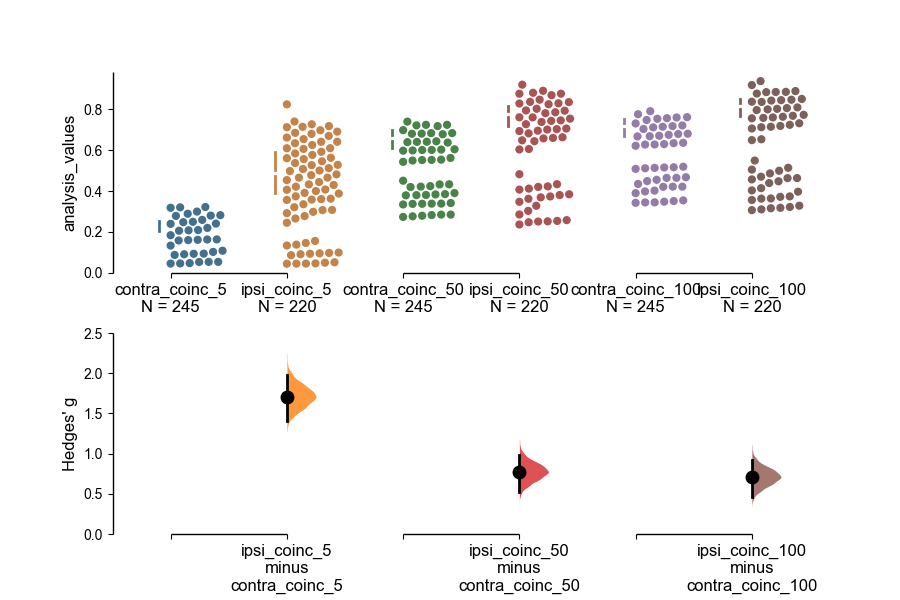

In [103]:
# Load the DataFrame into dabest
analysis_of_long_df = dabest.load(df_dabest, idx=(('contra_coinc_5','ipsi_coinc_5'),
                                                  ('contra_coinc_50','ipsi_coinc_50'),
                                                  ('contra_coinc_100','ipsi_coinc_100')), 
                                                  x="side_analysis", y="analysis_values")
analysis_of_long_df.hedges_g.plot(group_summaries = 'median_quartiles',float_contrast=False,contrast_ylim=(0, 2.5))


os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_ripple_coincidence_dabest.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


In [104]:

print(analysis_of_long_df.hedges_g)
analysis_of_long_df.hedges_g.results


DABEST v2024.03.29
                  
Good afternoon!
The current time is Sat Sep 28 13:58:28 2024.

The unpaired Hedges' g between contra_coinc_5 and ipsi_coinc_5 is 1.7 [95%CI 1.41, 1.98].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired Hedges' g between contra_coinc_50 and ipsi_coinc_50 is 0.769 [95%CI 0.528, 0.984].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired Hedges' g between contra_coinc_100 and ipsi_coinc_100 is 0.706 [95%CI 0.465, 0.919].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the resu

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,permutations,pvalue_permutation,permutation_count,permutations_var,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,contra_coinc_5,ipsi_coinc_5,245,220,Hedges' g,None,1.704184,95,1.412485,1.976241,...,"[0.21560382098082922, 0.10665045139419722, 0.0...",0.0,5000,"[0.00027168073268188245, 0.0002767791633959198...",3.363092e-48,-17.714512,4.778121e-57,-18.377607,2.104691e-45,6490.0
1,contra_coinc_50,ipsi_coinc_50,245,220,Hedges' g,None,0.769255,95,0.527532,0.983998,...,"[0.24787111585020935, 0.05185632493436008, 0.1...",0.0,5000,"[0.00019666887320809103, 0.0002033088479112357...",3.832045e-15,-8.174663,1.189174e-15,-8.295500,1.807813e-35,8967.0
2,contra_coinc_100,ipsi_coinc_100,245,220,Hedges' g,None,0.706003,95,0.464919,0.918775,...,"[0.24718691241477783, 0.051157257456820336, 0....",0.0,5000,"[0.00016064730625378712, 0.0001662678092241995...",3.771313e-13,-7.508662,1.512169e-13,-7.613405,2.759943e-35,9016.0


In [17]:

# os.chdir(tables_path + '/figure_6/')

# filename = 'Figure_Ripple_Coincidence_RippleEpochOverlap.csv'
# df = pd.read_csv(filename)
# df = df[df['shanks_distance'] != 1400]
# shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
# rat_mask = df['rat'] == 'Bud'
# df = df[~(shank_mask*rat_mask)]



In [18]:

# plt.close('all')
# plt.figure(figsize=(5,5))

# my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence", order=["ipsi", "contra"],
#               palette=my_pal,size=6,legend=False,alpha=1)

# box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence',
#             order=["ipsi", "contra"], showfliers=False, showcaps=False,
#             whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
#             medianprops=dict(linestyle='-', linewidth=1.5),
#             width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

# sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence',
#                palette=my_pal,fill=True,inner = None,split=True,
#                legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

# plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
# plt.xlabel('Shank side',fontsize=14)
# plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
# plt.ylim([-0.1,1.1])
# # we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# # plt.xticks([0,1],labels=['Left','Right'])
# plt.tight_layout()

# os.chdir(figures_path + '/figure_6/')
# fig_name = 'Figure_Ripple_Coincidence_RippleEpochOverlap.svg'

# # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# plt.show()
# # hf.delete_clip_path(fig_name)



In [106]:

os.chdir(tables_path + '/figure_6/')

filename = 'Figure_Ripple_CrossCorrelation_RippleEvents.csv'
df = pd.read_csv(filename)
df

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,side,shank_1,shank_2,shanks_distance,ripple_coincidence_100,ripple_coincidence_50,ripple_coincidence_5,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,1651.0,1519.0,1380.0,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,1544.0,1409.0,1097.0,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,1435.0,1291.0,841.0,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,1371.0,1212.0,663.0,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,1324.0,1144.0,568.0,5.0
...,...,...,...,...,...,...,...,...,...,...
461,Gat,Gatsby_08282013,ipsi,12,14,400.0,1830.0,1578.0,1182.0,2.0
462,Gat,Gatsby_08282013,ipsi,12,15,600.0,1552.0,1265.0,646.0,3.0
463,Gat,Gatsby_08282013,ipsi,13,14,200.0,1896.0,1645.0,1345.0,1.0
464,Gat,Gatsby_08282013,ipsi,13,15,400.0,1572.0,1294.0,672.0,2.0


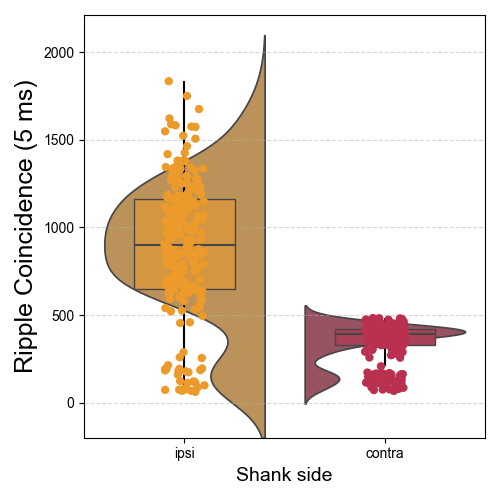

In [107]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence_5", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)

box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence_5',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence_5',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1,cut=2)

plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=-200)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_Ripple_CrossCorrelation_RippleEvents_5ms.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



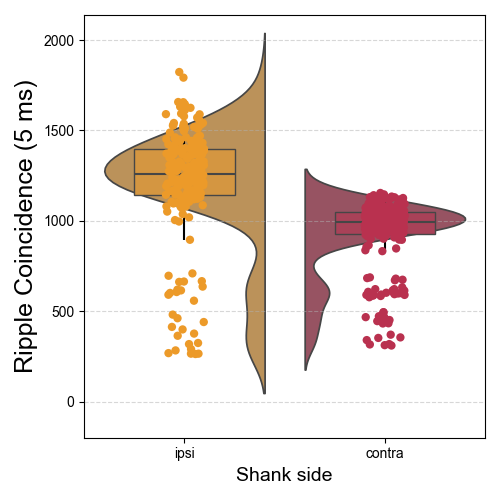

In [83]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence_50", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)

box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence_50',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence_50',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1,cut=2)

plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=-200)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_Ripple_CrossCorrelation_RippleEvents_50ms.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



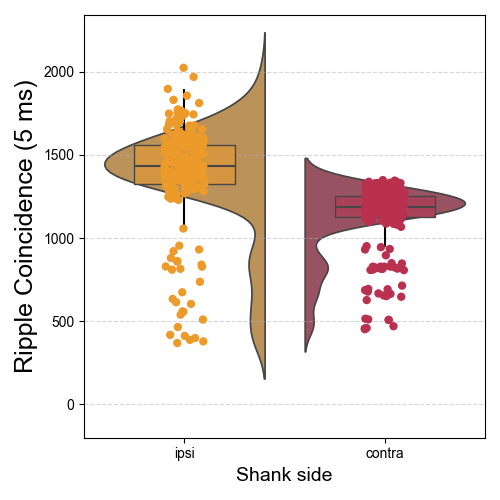

In [84]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="ripple_coincidence_100", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)

box = sns.boxplot(data=df, x='side', hue="side", y='ripple_coincidence_100',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='ripple_coincidence_100',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1,cut=2)

plt.ylabel('Ripple Coincidence (5 ms)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=-200)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_Ripple_CrossCorrelation_RippleEvents_100ms.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [108]:
rat = np.tile(df['rat'],3)
session = np.tile(df['session'],3)
side = np.tile(df['side'],3)
analysis_values = np.concatenate([df['ripple_coincidence_5'],df['ripple_coincidence_50'],df['ripple_coincidence_100']])
analysis_type = np.repeat(['coinc_5','coinc_50','coinc_100'],[len(df['ripple_coincidence_5']),len(df['ripple_coincidence_50']),len(df['ripple_coincidence_100'])])

data_dict = {'rat':rat,
            'session':session,
            'side':side,
            'analysis_type':analysis_type,
            'analysis_values':analysis_values
            }
df_dabest = pd.DataFrame(data_dict)
df_dabest['side_analysis'] = df_dabest['side'] + '_' + df_dabest['analysis_type']
df_dabest['coinc_value'] = df_dabest['analysis_type'].replace({'coinc_5': 5, 'coinc_50': 50, 'coinc_100': 100})
df_dabest

# coinc_value is continuous, analysis_type is categorical

,rat,session,side,analysis_type,analysis_values,side_analysis,coinc_value
0,Ach,Achilles_10252013,ipsi,coinc_5,1380.0,ipsi_coinc_5,5
1,Ach,Achilles_10252013,ipsi,coinc_5,1097.0,ipsi_coinc_5,5
2,Ach,Achilles_10252013,ipsi,coinc_5,841.0,ipsi_coinc_5,5
3,Ach,Achilles_10252013,ipsi,coinc_5,663.0,ipsi_coinc_5,5
4,Ach,Achilles_10252013,ipsi,coinc_5,568.0,ipsi_coinc_5,5
...,...,...,...,...,...,...,...
1393,Gat,Gatsby_08282013,ipsi,coinc_100,1830.0,ipsi_coinc_100,100
1394,Gat,Gatsby_08282013,ipsi,coinc_100,1552.0,ipsi_coinc_100,100
1395,Gat,Gatsby_08282013,ipsi,coinc_100,1896.0,ipsi_coinc_100,100
1396,Gat,Gatsby_08282013,ipsi,coinc_100,1572.0,ipsi_coinc_100,100


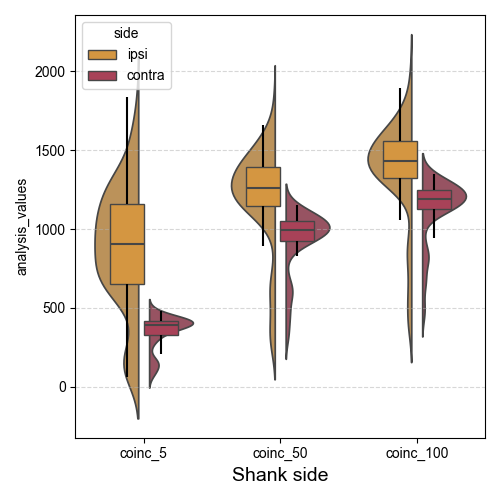

In [109]:

plt.figure(figsize=(5,5))
box = sns.boxplot(data=df_dabest, x='analysis_type', hue="side", y='analysis_values',
            order=['coinc_5','coinc_50','coinc_100'], hue_order=["ipsi", "contra"], 
            showfliers=False, showcaps=False, whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),palette=my_pal,
            width=0.5)  # Using the custom color palette
box = sns.violinplot(data=df_dabest, x='analysis_type', hue="side", y='analysis_values',
            order=['coinc_5','coinc_50','coinc_100'], hue_order=["ipsi", "contra"],
            palette=my_pal,fill=True,inner = None,split=True,gap = 0.2,
            legend=False,density_norm='width',saturation=0.5,bw_adjust=1)  # Using the custom color palette


plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.ylim([0,1])
plt.tight_layout()


os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_crosscorrelation_ripple_events.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


# plt.figure(figsize=(5,5))
# box = sns.boxplot(data=df_dabest, x='analysis_type', hue="side", y='analysis_values',
#             order=['coinc_5','coinc_50','coinc_100'], hue_order=["ipsi", "contra"], 
#             showfliers=True, showcaps=False, whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
#             medianprops=dict(linestyle='-', linewidth=1.5),
#             width=0.5)  # Using the custom color palette

# plt.xlabel('Shank side',fontsize=14)
# plt.grid(linestyle='--',alpha=0.5,axis='y')
# # plt.ylim([0,1])
# plt.tight_layout()
# plt.show()




In [110]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "analysis_values ~ C(side, Treatment(reference='ipsi')) * coinc_value"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_dabest,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())




/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                                    Mixed Linear Model Regression Results
Model:                            MixedLM                 Dependent Variable:                 analysis_values
No. Observations:                 1398                    Method:                             REML           
No. Groups:                       4                       Scale:                              54743.8785     
Min. group size:                  108                     Log-Likelihood:                     -9616.4110     
Max. group size:                  594                     Converged:                          Yes            
Mean group size:                  349.5                                                                      
-------------------------------------------------------------------------------------------------------------
                                                             Coef.   Std.Err.    z    P>|z|  [0.025   0.975] 
----------------------------------------------

In [89]:
result.pvalues

Intercept                                                      3.115635e-22
C(side, Treatment(reference='ipsi'))[T.contra]                2.308578e-135
coinc_value                                                   1.399757e-108
C(side, Treatment(reference='ipsi'))[T.contra]:coinc_value     9.007917e-20
rat Var                                                        2.724057e-01
session Var                                                    1.774191e-01
dtype: float64

In [88]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's posthoc test
posthoc = pairwise_tukeyhsd(df_dabest['analysis_values'], df_dabest['side_analysis'])
# Print the results
print(posthoc)


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1           group2      meandiff p-adj    lower     upper   reject
----------------------------------------------------------------------------
contra_coinc_100  contra_coinc_5 -780.2358    0.0 -848.8058 -711.6657   True
contra_coinc_100 contra_coinc_50 -201.3618    0.0 -269.9319 -132.7917   True
contra_coinc_100  ipsi_coinc_100  249.0529    0.0  178.4859  319.6198   True
contra_coinc_100    ipsi_coinc_5  -247.738    0.0  -318.305 -177.1711   True
contra_coinc_100   ipsi_coinc_50   78.2938 0.0196    7.7269  148.8607   True
  contra_coinc_5 contra_coinc_50   578.874    0.0  510.3039  647.4441   True
  contra_coinc_5  ipsi_coinc_100 1029.2887    0.0  958.7217 1099.8556   True
  contra_coinc_5    ipsi_coinc_5  532.4977    0.0  461.9308  603.0647   True
  contra_coinc_5   ipsi_coinc_50  858.5296    0.0  787.9626  929.0965   True
 contra_coinc_50  ipsi_coinc_100  450.4147    0.0  379.8477  520.9816   True

In [25]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "analysis_values ~ C(side, Treatment(reference='ipsi')) * C(analysis_type,Treatment(reference='coinc_5'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_dabest,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())




                                                             Mixed Linear Model Regression Results
Model:                                              MixedLM                                 Dependent Variable:                                 analysis_values
No. Observations:                                   1398                                    Method:                                             REML           
No. Groups:                                         4                                       Scale:                                              48770.4291     
Min. group size:                                    108                                     Log-Likelihood:                                     -9518.5870     
Max. group size:                                    594                                     Converged:                                          Yes            
Mean group size:                                    349.5                                            

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's posthoc test
posthoc = pairwise_tukeyhsd(df_dabest['analysis_values'], df_dabest['side_analysis'])
# Print the results
print(posthoc)


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1           group2      meandiff p-adj    lower     upper   reject
----------------------------------------------------------------------------
contra_coinc_100  contra_coinc_5 -780.2358    0.0 -848.8058 -711.6657   True
contra_coinc_100 contra_coinc_50 -201.3618    0.0 -269.9319 -132.7917   True
contra_coinc_100  ipsi_coinc_100  249.0529    0.0  178.4859  319.6198   True
contra_coinc_100    ipsi_coinc_5  -247.738    0.0  -318.305 -177.1711   True
contra_coinc_100   ipsi_coinc_50   78.2938 0.0196    7.7269  148.8607   True
  contra_coinc_5 contra_coinc_50   578.874    0.0  510.3039  647.4441   True
  contra_coinc_5  ipsi_coinc_100 1029.2887    0.0  958.7217 1099.8556   True
  contra_coinc_5    ipsi_coinc_5  532.4977    0.0  461.9308  603.0647   True
  contra_coinc_5   ipsi_coinc_50  858.5296    0.0  787.9626  929.0965   True
 contra_coinc_50  ipsi_coinc_100  450.4147    0.0  379.8477  520.9816   True

In [27]:
import pingouin as pg
import warnings

# Suppress RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)


posthoc_result = pg.pairwise_tests(dv='analysis_values', within='side_analysis',
                                   between='rat', subject='session', data=df_dabest,
                                   parametric=True, padjust='bonf')
posthoc_result


,Contrast,side_analysis,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,side_analysis,-,contra_coinc_100,contra_coinc_5,True,True,26.579908,7.000000,two-sided,2.732613e-08,4.098920e-07,bonf,2.836e+05,4.566041
1,side_analysis,-,contra_coinc_100,contra_coinc_50,True,True,33.928919,7.000000,two-sided,5.007183e-09,7.510775e-08,bonf,1.21e+06,0.983191
2,side_analysis,-,contra_coinc_100,ipsi_coinc_100,True,True,-4.979131,7.000000,two-sided,1.602556e-03,2.403835e-02,bonf,28.126,-1.356667
3,side_analysis,-,contra_coinc_100,ipsi_coinc_5,True,True,4.650278,7.000000,two-sided,2.341109e-03,3.511664e-02,bonf,20.719,1.052228
4,side_analysis,-,contra_coinc_100,ipsi_coinc_50,True,True,-1.961277,7.000000,two-sided,9.064891e-02,1.000000e+00,bonf,1.227,-0.480253
5,side_analysis,-,contra_coinc_5,contra_coinc_50,True,True,-17.862212,7.000000,two-sided,4.254997e-07,6.382495e-06,bonf,2.73e+04,-3.207781
6,side_analysis,-,contra_coinc_5,ipsi_coinc_100,True,True,-21.459216,7.000000,two-sided,1.202516e-07,1.803775e-06,bonf,8.009e+04,-6.159419
7,side_analysis,-,contra_coinc_5,ipsi_coinc_5,True,True,-11.504101,7.000000,two-sided,8.435891e-06,1.265384e-04,bonf,2172.686,-2.931369
8,side_analysis,-,contra_coinc_5,ipsi_coinc_50,True,True,-17.854229,7.000000,two-sided,4.268077e-07,6.402115e-06,bonf,2.723e+04,-4.847280
9,side_analysis,-,contra_coinc_50,ipsi_coinc_100,True,True,-8.714664,7.000000,two-sided,5.257588e-05,7.886383e-04,bonf,468.007,-2.295492


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 88.2% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 63.6% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 82.1% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 70.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 83.3% of th

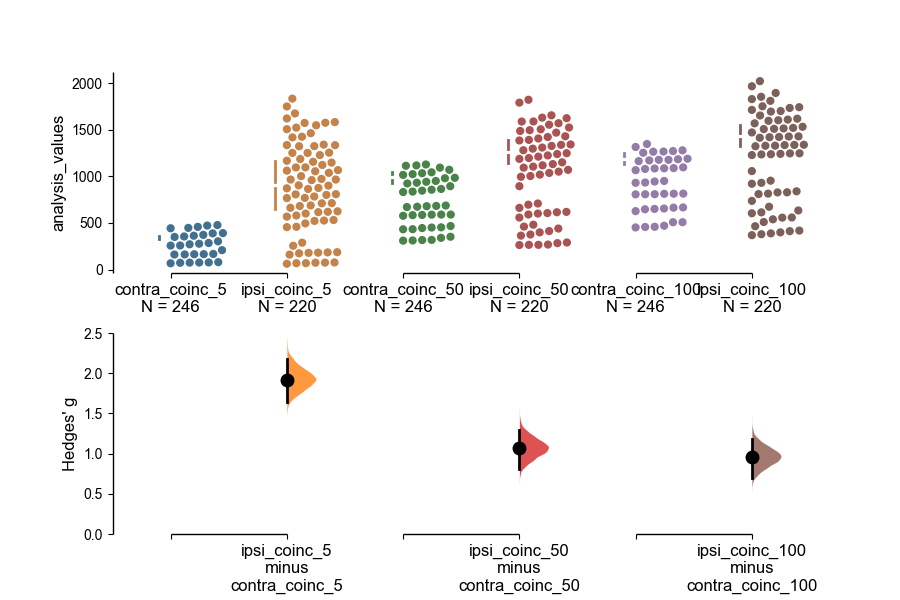

In [111]:
# Load the DataFrame into dabest
analysis_of_long_df = dabest.load(df_dabest, idx=(('contra_coinc_5','ipsi_coinc_5'),
                                                  ('contra_coinc_50','ipsi_coinc_50'),
                                                  ('contra_coinc_100','ipsi_coinc_100')), 
                                                  x="side_analysis", y="analysis_values")
analysis_of_long_df.hedges_g.plot(group_summaries = 'median_quartiles',float_contrast=False,contrast_ylim=(0, 2.5))



os.chdir(figures_path + '/figure_6/')
fig_name = 'Figure_crosscorrelation_ripple_events_dabest.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


In [112]:
print(analysis_of_long_df.hedges_g)
analysis_of_long_df.hedges_g.results

DABEST v2024.03.29
                  
Good afternoon!
The current time is Sat Sep 28 14:05:04 2024.

The unpaired Hedges' g between contra_coinc_5 and ipsi_coinc_5 is 1.92 [95%CI 1.64, 2.18].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired Hedges' g between contra_coinc_50 and ipsi_coinc_50 is 1.07 [95%CI 0.804, 1.3].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired Hedges' g between contra_coinc_100 and ipsi_coinc_100 is 0.957 [95%CI 0.699, 1.18].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,permutations,pvalue_permutation,permutation_count,permutations_var,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,contra_coinc_5,ipsi_coinc_5,246,220,Hedges' g,None,1.917719,95,1.637331,2.176636,...,"[0.10253608680359755, 0.08559865218593503, 0.1...",0.0,5000,"[1261.5267115509828, 1280.9809905431073, 1269....",6.677283e-53,-19.734958,6.579517e-68,-20.700165,9.978654e-48,5997.0
1,contra_coinc_50,ipsi_coinc_50,246,220,Hedges' g,None,1.065127,95,0.804381,1.295370,...,"[0.20720196161607335, 0.08764504660467254, 0.1...",0.0,5000,"[738.9612068893557, 760.28884383815, 748.91715...",2.779668e-25,-11.223458,4.326989e-27,-11.497153,1.507653e-42,7219.0
2,contra_coinc_100,ipsi_coinc_100,246,220,Hedges' g,None,0.957161,95,0.698931,1.184302,...,"[0.22469353621837632, 0.08694891336002993, 0.1...",0.0,5000,"[691.2568044026967, 714.6792700201979, 703.052...",2.763397e-21,-10.092120,1.164445e-22,-10.331751,1.248823e-41,7443.5
